=== Étape 3 : Score Métier ===



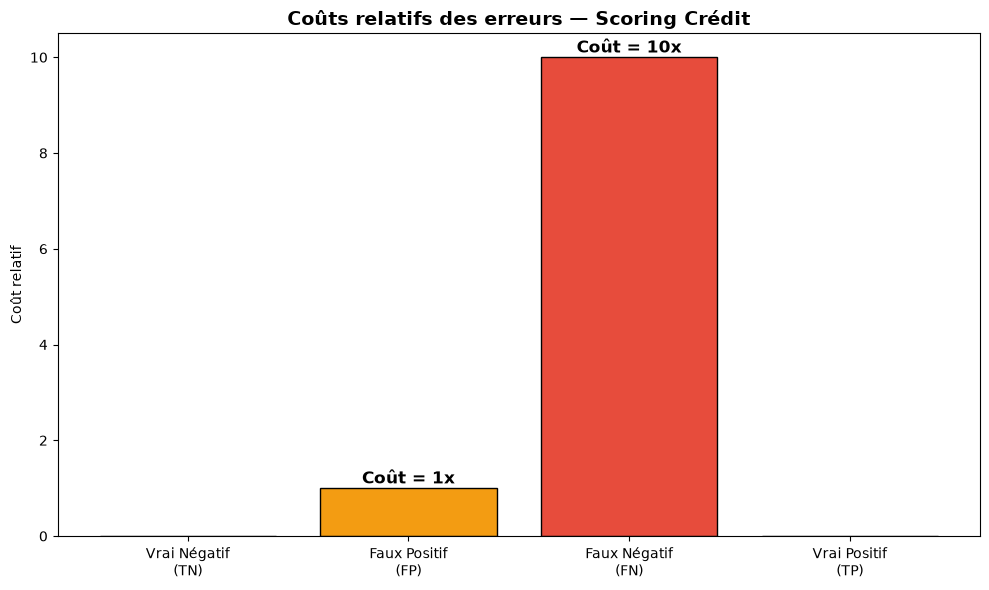

✅ Coût Faux Négatif (FN) : 10x
✅ Coût Faux Positif (FP) : 1x

📌 Formule : Score = (10 × FN) + (1 × FP)
📌 Objectif : Minimiser ce score !


In [1]:
# Cellule 1 — Définition du score métier
print("=== Étape 3 : Score Métier ===\n")

# Dans le scoring crédit, les erreurs n'ont pas le même coût :
#
# Faux Négatif (FN) : On accorde un crédit à quelqu'un qui va faire défaut
#                     → La banque perd l'argent prêté
#                     → TRÈS COÛTEUX (ex: 10x plus grave)
#
# Faux Positif (FP) : On refuse un crédit à quelqu'un qui aurait remboursé
#                     → La banque perd un client et des intérêts
#                     → MOINS COÛTEUX (ex: 1x)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Définition des coûts
COUT_FN = 10  # Accorder crédit à mauvais payeur (grave)
COUT_FP = 1   # Refuser crédit à bon payeur (moins grave)

def score_metier(y_true, y_pred, cout_fn=COUT_FN, cout_fp=COUT_FP):
    """
    Score métier basé sur les coûts relatifs FP/FN
    Plus le score est bas, meilleur est le modèle
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    cout_total = (cout_fn * fn) + (cout_fp * fp)
    return cout_total

# Visualisation des coûts
fig, ax = plt.subplots(figsize=(10, 6))

categories = ['Vrai Négatif\n(TN)', 'Faux Positif\n(FP)', 
              'Faux Négatif\n(FN)', 'Vrai Positif\n(TP)']
couts = [0, COUT_FP, COUT_FN, 0]
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#2ecc71']

bars = ax.bar(categories, couts, color=colors, edgecolor='black')
ax.set_title('Coûts relatifs des erreurs — Scoring Crédit', 
             fontsize=14, fontweight='bold')
ax.set_ylabel('Coût relatif')

for bar, cout in zip(bars, couts):
    if cout > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'Coût = {cout}x', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print(f"✅ Coût Faux Négatif (FN) : {COUT_FN}x")
print(f"✅ Coût Faux Positif (FP) : {COUT_FP}x")
print(f"\n📌 Formule : Score = ({COUT_FN} × FN) + ({COUT_FP} × FP)")
print(f"📌 Objectif : Minimiser ce score !")

=== Démonstration du Score Métier ===



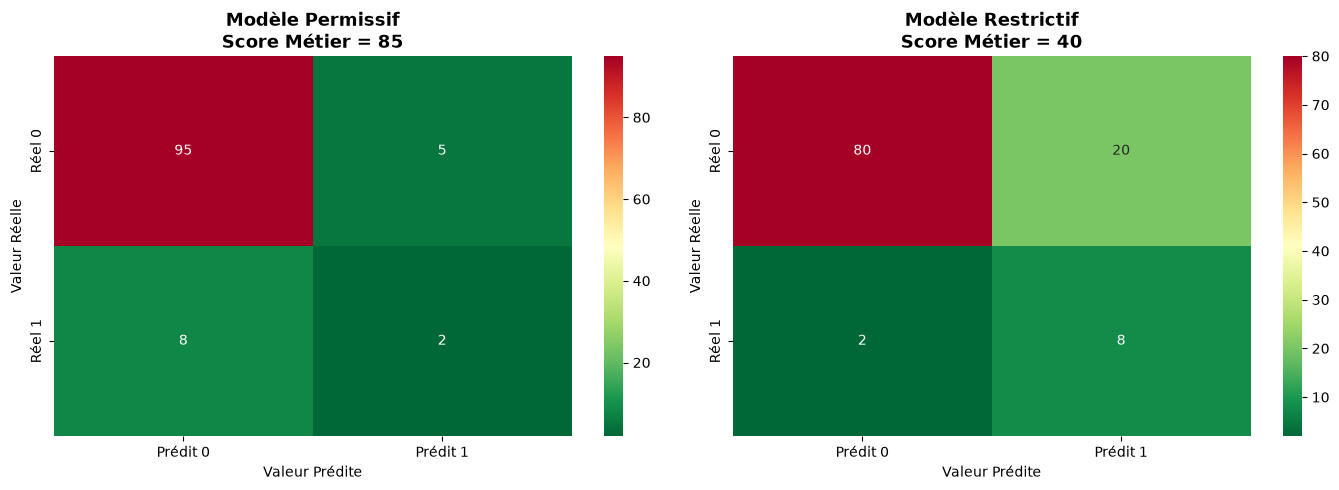

Modèle permissif  → Score métier : 85
Modèle restrictif → Score métier : 40

💡 Le modèle avec le score le plus BAS est le meilleur !


In [3]:
# Cellule 2 — Démonstration avec matrice de confusion
print("=== Démonstration du Score Métier ===\n")

import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

np.random.seed(42)
y_true_exemple = np.array([0]*100 + [1]*10)

# Modèle permissif
y_pred_permissif = np.array([0]*95 + [1]*5 + [0]*8 + [1]*2)

# Modèle restrictif
y_pred_restrictif = np.array([0]*80 + [1]*20 + [0]*2 + [1]*8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (y_pred, titre) in zip(axes, [
    (y_pred_permissif, "Modèle Permissif"),
    (y_pred_restrictif, "Modèle Restrictif")
]):
    cm = confusion_matrix(y_true_exemple, y_pred)
    score = score_metier(y_true_exemple, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn_r', ax=ax,
                xticklabels=['Prédit 0', 'Prédit 1'],
                yticklabels=['Réel 0', 'Réel 1'])
    ax.set_title(f'{titre}\nScore Métier = {score}', 
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('Valeur Réelle')
    ax.set_xlabel('Valeur Prédite')

plt.tight_layout()
plt.show()

print(f"Modèle permissif  → Score métier : {score_metier(y_true_exemple, y_pred_permissif)}")
print(f"Modèle restrictif → Score métier : {score_metier(y_true_exemple, y_pred_restrictif)}")
print(f"\n💡 Le modèle avec le score le plus BAS est le meilleur !")